# Team Value Over Time

The capstone validation: reconstruct each franchise's **total dynasty value** (players + picks)
on a weekly grid back to the 2021 startup, from the SCD2 ownership ledger × point-in-time values.

- **Ownership** comes from the locally-built SCD2 ledger (`fact_roster_membership` — players + picks,
  history to 2021). *Not yet in GCS (PR #4 unmerged), so it's read from `analysis/_cache/`.*
- **Value** lenses: **KTC** (full history ~2020→) and **FantasyCalc** (better market signal, ~2025-10→).
- Picks are valued at the **round level** (KTC tier=Mid; FC round-generic "YYYY Nth") for transparency.

If a team's curve looks wrong, it points back at the ledger/value data — that's the point.

In [1]:
import sys; sys.path.insert(0, ".")
import fantasy_lib as F
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date

pl.Config.set_tbl_rows(15)
CACHE = F.CACHE  # analysis/_cache (for saving figures)

In [2]:
# --- load ownership + dims ---
ledger = F.load_ledger()
franchises, players = F.load_dims()
fr_meta = franchises.select("franchise_id", "league_lineage_id", "current_team_name", "roster_id")

print(f"ledger intervals: {ledger.height:,}  ({ledger.filter(pl.col('asset_type')=='player').height:,} player + "
      f"{ledger.filter(pl.col('asset_type')=='pick').height:,} pick)")
lineage_ids = fr_meta["league_lineage_id"].unique().to_list()
print("lineages:", lineage_ids)

ledger intervals: 5,500  (4,353 player + 1,147 pick)
lineages: ['730630605066371072', '1061511485920354304', '1131624152349323264']


In [3]:
# --- value inputs (load once, reuse for both lenses) ---
pv = F.load_player_values()                 # SF / Standard / DYNASTY ; ktc_value + fc_value
pk_ktc = F.load_pick_values_round("ktc")
pk_fc  = F.load_pick_values_round("fc")
print(f"player values: {pv.height:,} rows  ({pv['valuation_date'].min()} -> {pv['valuation_date'].max()})")
print(f"pick(round) values  KTC: {pk_ktc.height:,}   FC: {pk_fc.height:,}")

player values: 562,568 rows  (2020-04-01 -> 2026-06-13)
pick(round) values  KTC: 17,247   FC: 74,592


In [4]:
# --- build the measure on a weekly grid, both lenses ---
# Grid ends at the last continuous snapshot week. The single post-rollover 2026
# snapshot sits after an ~8-month frozen-roster gap, so including it spikes the
# lines; the current-state check below uses a standalone as-of-today snapshot instead.
DATES = F.weekly_dates("2021-09-01", "2026-06-07")
tv_ktc = F.team_value_timeseries(ledger, "ktc", DATES, player_values=pv, pick_values=pk_ktc)
tv_fc  = F.team_value_timeseries(ledger, "fc",  DATES, player_values=pv, pick_values=pk_fc)

def label(df):
    return df.join(fr_meta, on="franchise_id", how="left")
tv_ktc, tv_fc = label(tv_ktc), label(tv_fc)
print("KTC:", tv_ktc.height, "rows |", tv_ktc["franchise_id"].n_unique(), "franchises")
print("FC :", tv_fc.height,  "rows |", tv_fc.filter(pl.col('total_value')>0)['date'].min(), "first non-zero")

KTC: 4748 rows | 34 franchises
FC : 4748 rows | 2023-05-17 first non-zero


C:\Users\simer\Coding Project\Fantasy Analysis\analysis\.\fantasy_lib.py:230: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  hold.filter(pl.col("asset_type") == "player")
C:\Users\simer\Coding Project\Fantasy Analysis\analysis\.\fantasy_lib.py:243: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  hold.filter(pl.col("asset_type") == "pick")


## Validation: current holdings reproduce KTC's team index
As-of-today snapshot (standalone, independent of the weekly grid). `ktc_index` is players-only on KTC's 1-99 scale — it should track KTC's league power rankings.

In [5]:
# Current holdings valued as-of today -> should reproduce KTC's team values.
LIN = "730630605066371072"  # the 2021 'Stuck' lineage (deepest history)
LATEST = pv["valuation_date"].max().isoformat()
snap = (F.team_value_timeseries(ledger, "ktc", [LATEST], player_values=pv, pick_values=pk_ktc)
        .join(fr_meta, on="franchise_id", how="left")
        .filter(pl.col("league_lineage_id") == LIN))
snap = (snap.with_columns(
            (99 * pl.col("player_value") / pl.col("player_value").max()).round(0).alias("ktc_index"))
        .sort("player_value", descending=True)
        .select("current_team_name", "player_value", "pick_value", "total_value", "ktc_index"))
print(f"Current holdings as of {LATEST} — lineage {LIN} (ktc_index = players-only, KTC 1-99 scale):")
snap

Current holdings as of 2026-06-13 — lineage 730630605066371072 (ktc_index = players-only, KTC 1-99 scale):


current_team_name,player_value,pick_value,total_value,ktc_index
str,i64,i64,i64,f64
"""Jacob Simerly""",122068,21145,143213,99.0
"""Brayton Green""",118964,13066,132030,96.0
"""Timmy Becker""",116305,27875,144180,94.0
"""Noah Smyth""",110273,17699,127972,89.0
"""Alex Piroozi""",109093,22650,131743,88.0
"""Alex Vaught""",107150,21145,128295,87.0
"""Spencer Carella""",88980,30058,119038,72.0
"""Jake Kliest""",85436,15606,101042,69.0
"""Anthony Golden""",82942,15522,98464,67.0


In [6]:
# coverage per lineage: first week each lineage has any value
cov = (tv_ktc.filter(pl.col("total_value")>0).group_by("league_lineage_id")
       .agg(pl.col("date").min().alias("first_value_week"),
            pl.col("franchise_id").n_unique().alias("franchises")))
cov

league_lineage_id,first_value_week,franchises
str,date,u32
"""1131624152349323264""",2024-08-28,12
"""730630605066371072""",2021-09-08,10
"""1061511485920354304""",2024-08-07,12


## The graph — KTC, faceted by lineage
One line per franchise. Vertical markers = rookie drafts (value steps **up** as picks become players).

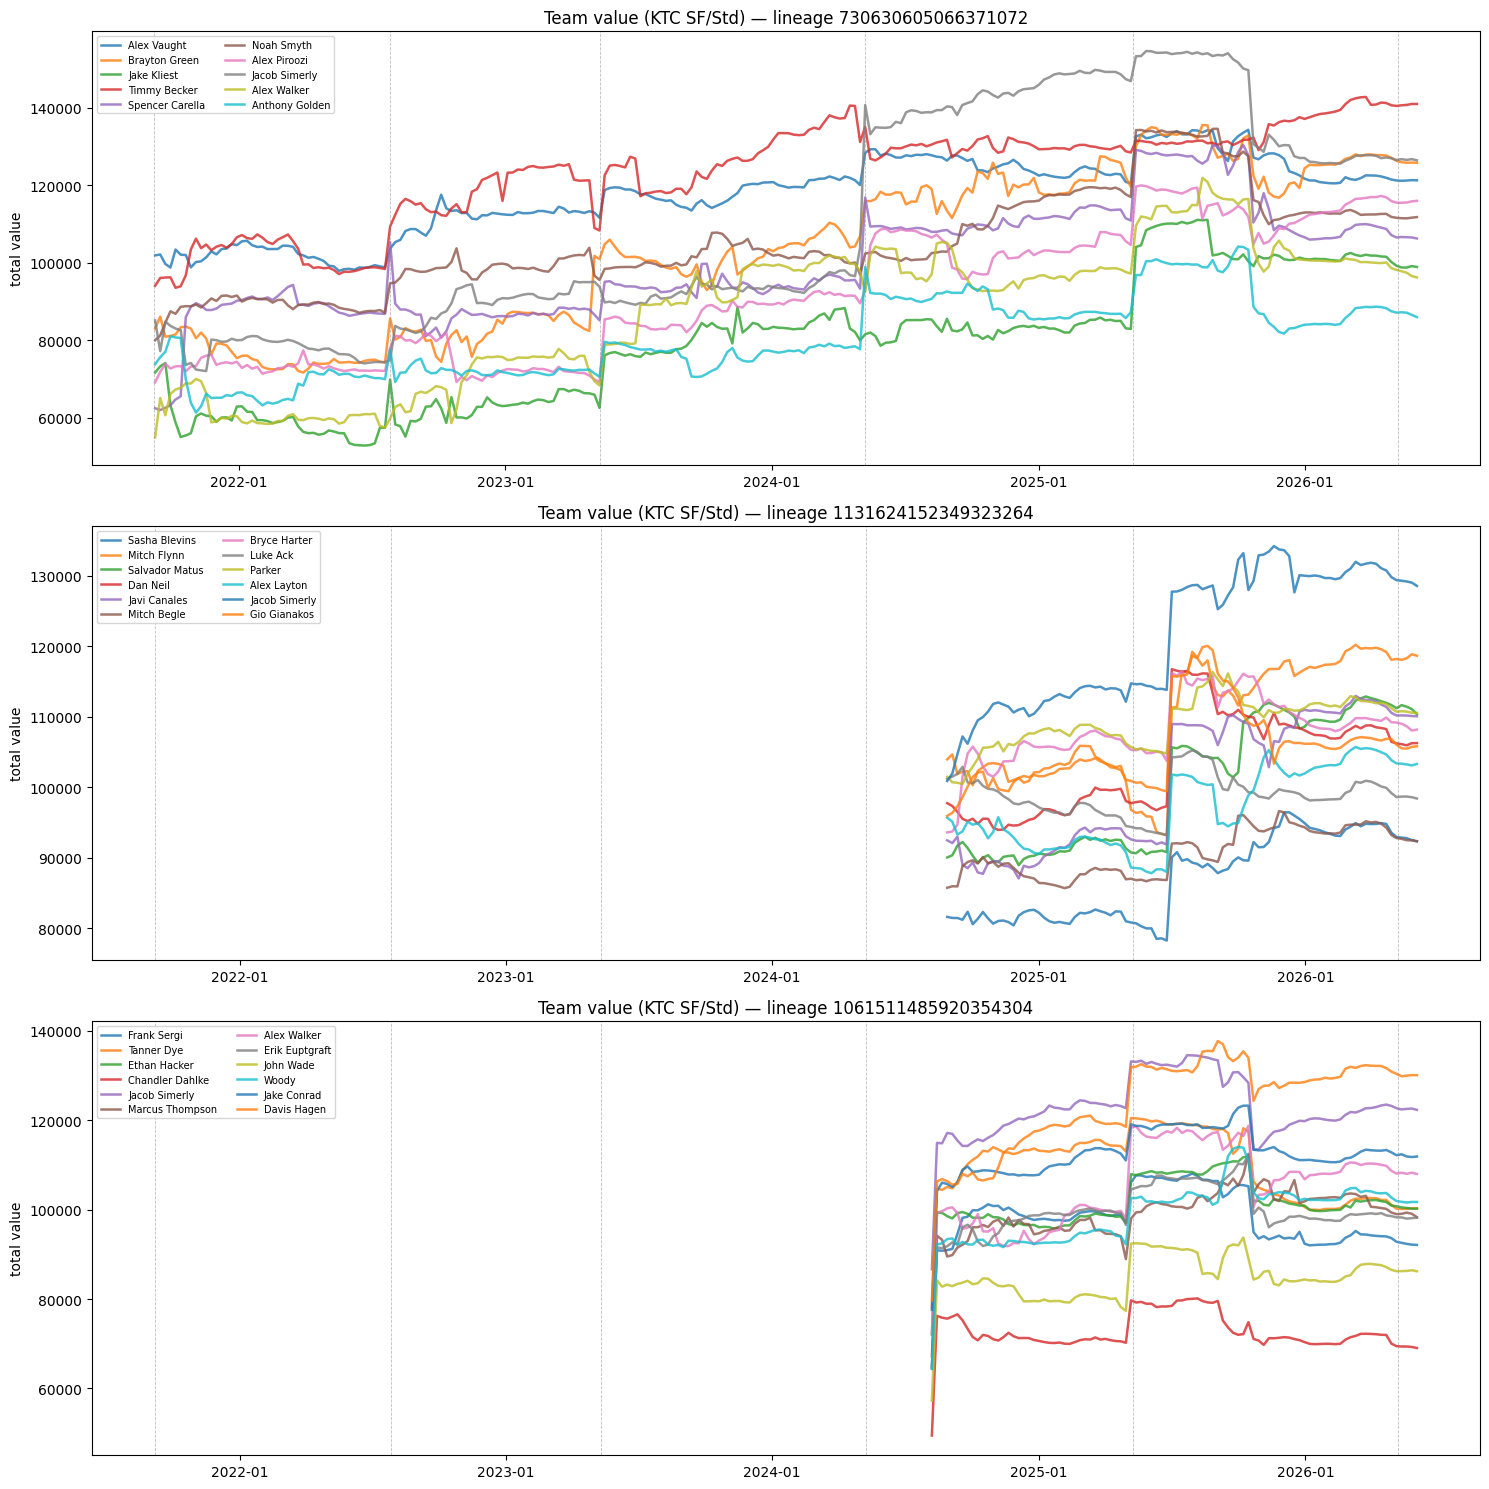

In [7]:
DRAFT_DATES = ["2021-09-07","2022-07-27","2023-05-11","2024-05-08","2025-05-10","2026-05-08"]

def plot_lineages(tv, title, value_floor=0):
    lins = [l for l in tv["league_lineage_id"].unique().to_list() if l is not None]
    fig, axes = plt.subplots(len(lins), 1, figsize=(15, 5*len(lins)), squeeze=False)
    for ax, lin in zip(axes[:,0], lins):
        sub = tv.filter((pl.col("league_lineage_id")==lin) & (pl.col("total_value")>value_floor))
        for fid in sub["franchise_id"].unique().to_list():
            s = sub.filter(pl.col("franchise_id")==fid).sort("date")
            if s.height == 0: continue
            name = s["current_team_name"][0] or fid
            ax.plot([d for d in s["date"]], s["total_value"].to_list(), label=name, linewidth=1.8, alpha=0.8)
        for dd in DRAFT_DATES:
            ax.axvline(date.fromisoformat(dd), color="gray", ls="--", lw=0.6, alpha=0.5)
        ax.set_title(f"{title} — lineage {lin}")
        ax.set_ylabel("total value"); ax.legend(fontsize=7, ncol=2, loc="upper left")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.tight_layout()
    return fig

fig = plot_lineages(tv_ktc, "Team value (KTC SF/Std)")
fig.savefig(CACHE/"tvot_ktc.png", dpi=90, bbox_inches="tight")
plt.show()

## The same graph — FantasyCalc (recent window only, ~2025-10→)

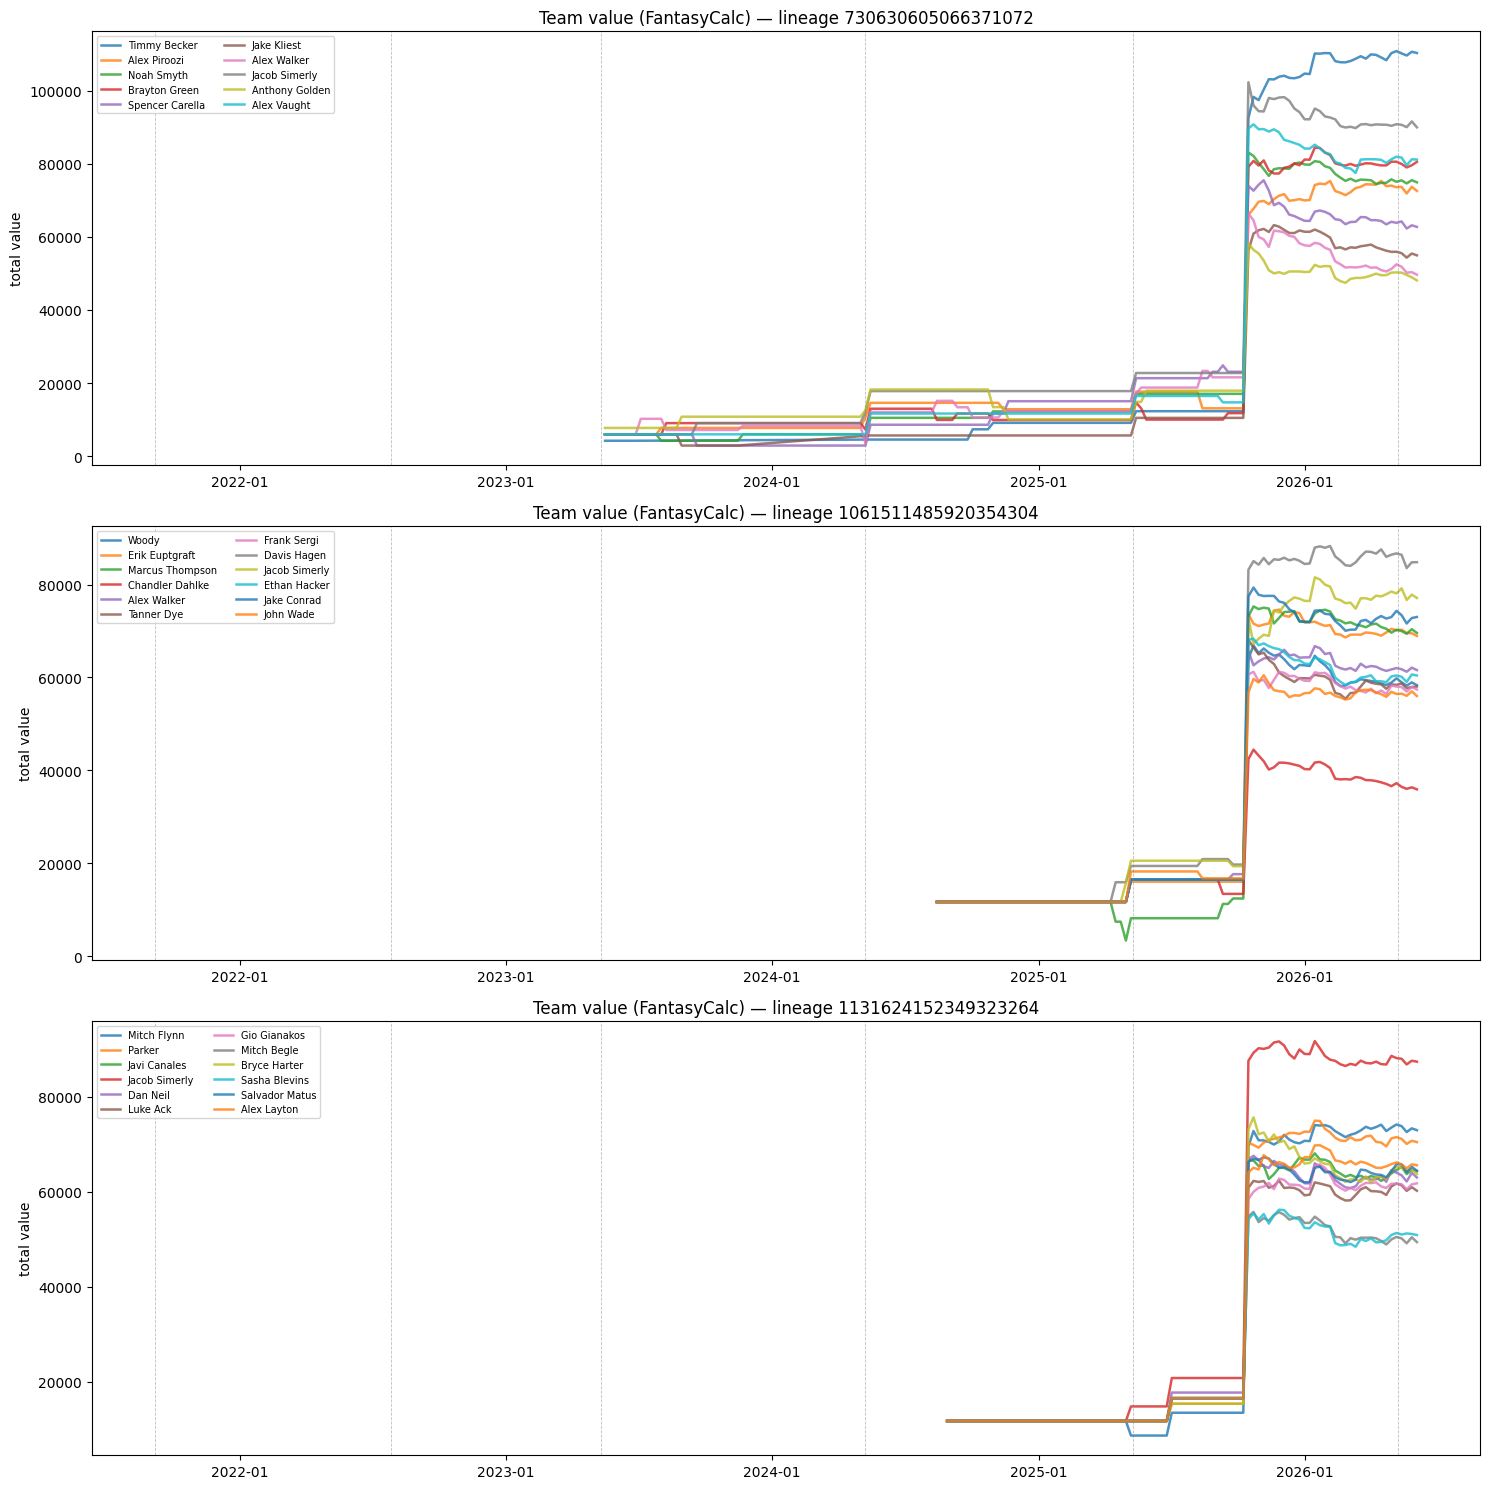

In [8]:
fig = plot_lineages(tv_fc, "Team value (FantasyCalc)", value_floor=0)
fig.savefig(CACHE/"tvot_fc.png", dpi=90, bbox_inches="tight")
plt.show()

## Normalized view — KTC's 1-99 power index
Each team on KTC's own scale: the **top team in the league that week = 99**, everyone else scales off it. Computed on **player value (picks excluded)**, exactly like KTC's league power rankings — the apples-to-apples view against KTC.

In [9]:
tvk_plus, agg_k = F.league_diagnostics(tv_ktc, fr_meta)
print("KTC league weekly aggregates:", agg_k.height, "rows")
agg_k.tail(5)

KTC league weekly aggregates: 437 rows


league_lineage_id,date,league_mean,league_total,lg_players_valued,n_teams,val_per_valued,wow_pct,d_players
str,date,f64,i64,u32,u32,f64,f64,i64
"""730630605066371072""",2026-05-06,113205.7,1132057,259,10,4370.876448,-0.4,0
"""730630605066371072""",2026-05-13,113131.0,1131310,259,10,4367.992278,-0.1,0
"""730630605066371072""",2026-05-20,113060.9,1130609,259,10,4365.285714,-0.1,0
"""730630605066371072""",2026-05-27,113056.7,1130567,259,10,4365.123552,-0.0,0
"""730630605066371072""",2026-06-03,112901.3,1129013,259,10,4359.123552,-0.1,0


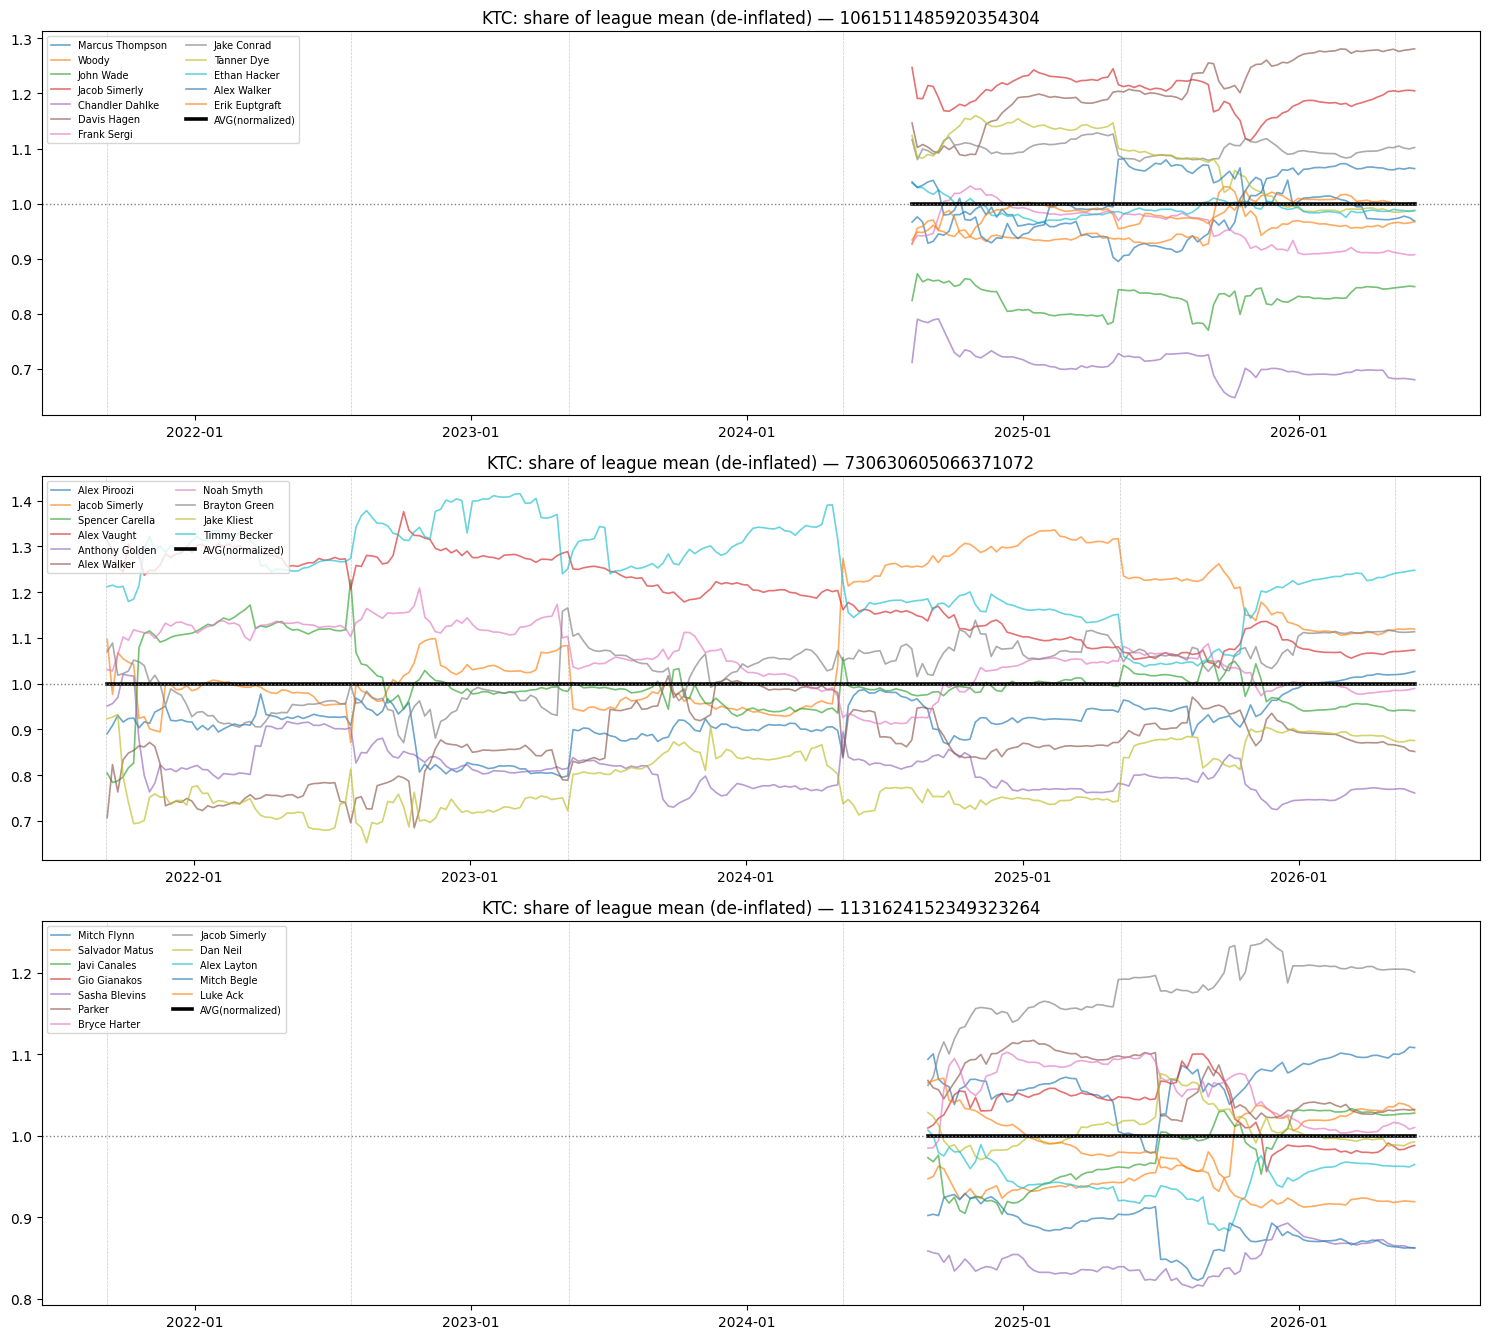

In [10]:
def plot_norm(tv_plus, col, title, ref=None):
    lins=[l for l in tv_plus["league_lineage_id"].unique().to_list() if l is not None]
    fig,axes=plt.subplots(len(lins),1,figsize=(15,4.5*len(lins)),squeeze=False)
    for ax,lin in zip(axes[:,0],lins):
        sub=tv_plus.filter((pl.col("league_lineage_id")==lin)&(pl.col("total_value")>0))
        for fid in sub["franchise_id"].unique().to_list():
            s=sub.filter(pl.col("franchise_id")==fid).sort("date")
            ax.plot([d for d in s["date"]], s[col].to_list(), lw=1.2, alpha=0.65,
                    label=(s["current_team_name"][0] or fid))
        avg=sub.group_by("date").agg(pl.col(col).mean().alias("m")).sort("date")
        ax.plot([d for d in avg["date"]], avg["m"].to_list(), color="black", lw=2.6, label="AVG(normalized)")
        if ref is not None: ax.axhline(ref, color="gray", ls=":", lw=1)
        for dd in DRAFT_DATES: ax.axvline(date.fromisoformat(dd), color="gray", ls="--", lw=0.5, alpha=0.4)
        ax.set_title(f"{title} — {lin}"); ax.legend(fontsize=7, ncol=2, loc="upper left")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.tight_layout(); return fig

fig=plot_norm(tvk_plus,"share","KTC: share of league mean (de-inflated)",ref=1.0)
fig.savefig(CACHE/"tvot_ktc_share.png",dpi=90,bbox_inches="tight"); plt.show()

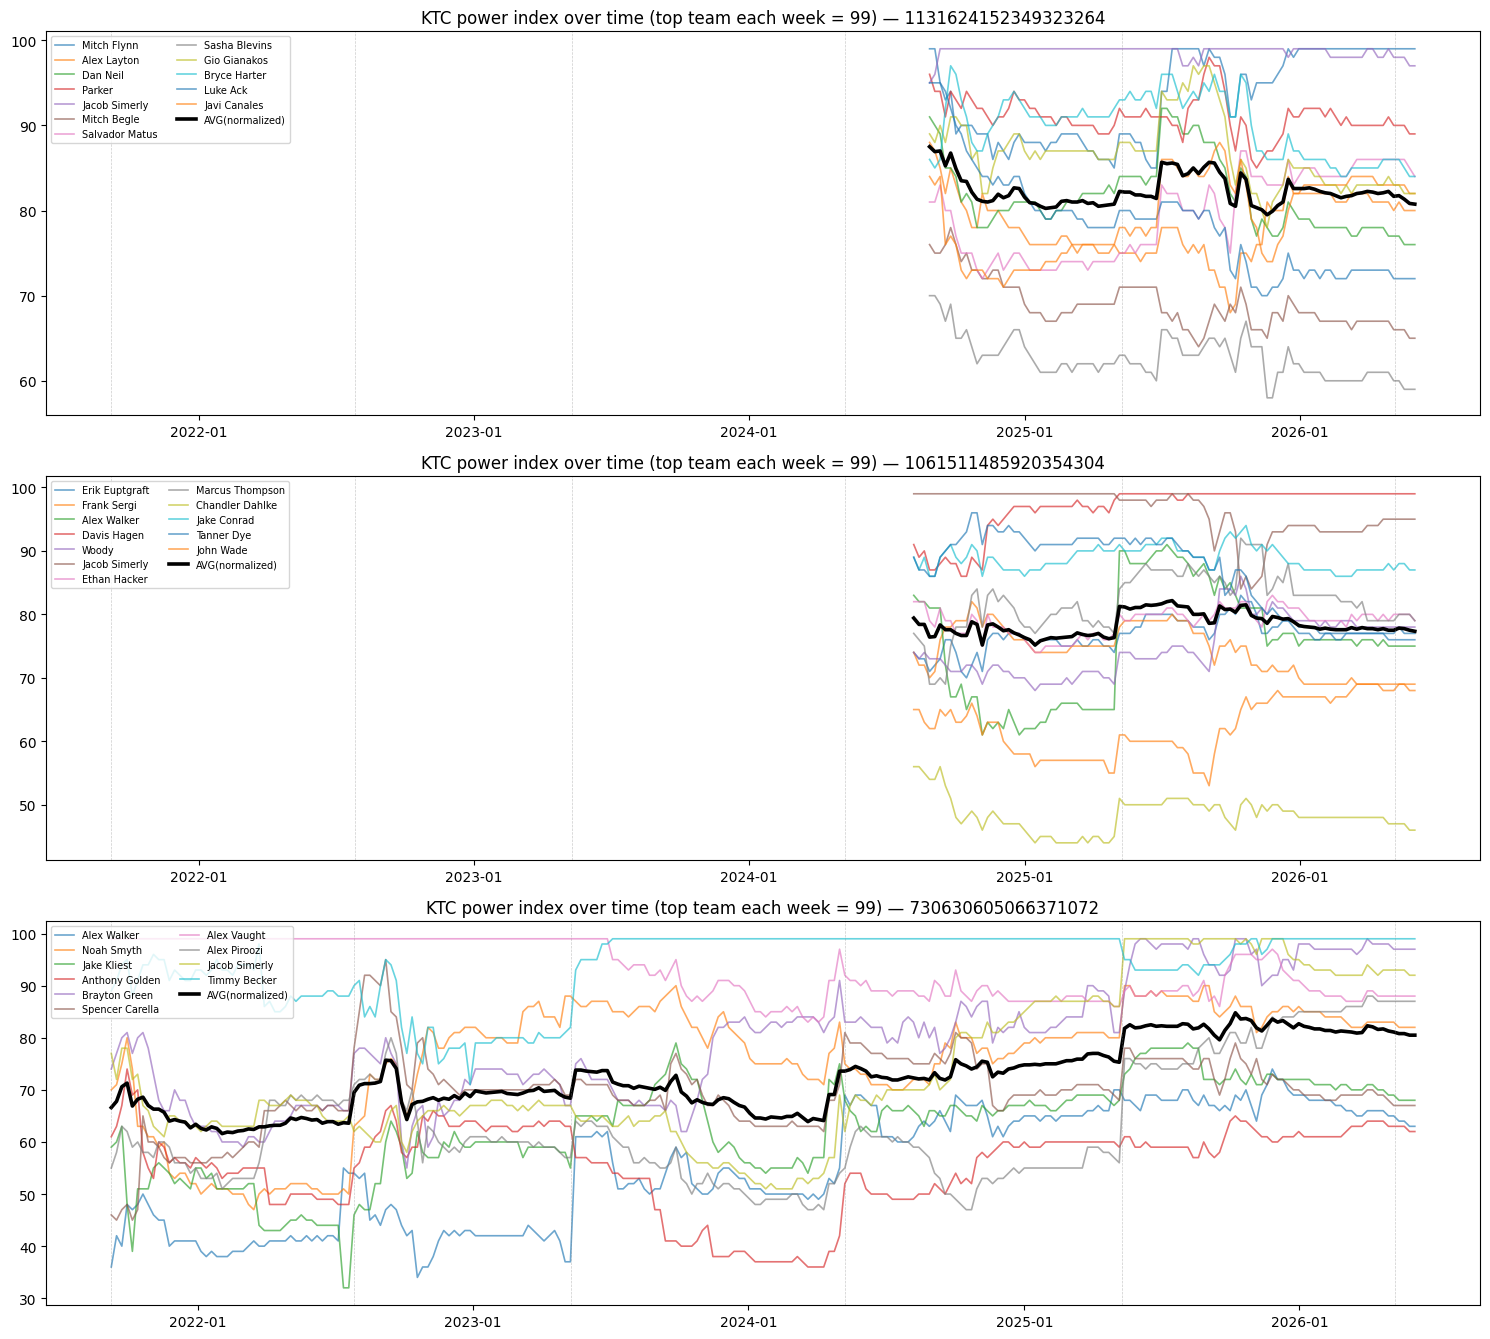

In [11]:
fig=plot_norm(tvk_plus,"ktc_index","KTC power index over time (top team each week = 99)")
fig.savefig(CACHE/"tvot_ktc_index99.png",dpi=90,bbox_inches="tight"); plt.show()

### Spike attribution (the actual data)
Weeks where the **league-mean** jumps >= 6% w/w. `d_players` = league-wide change in valued-player
count (coverage); `val_per_valued` = league total / players valued (per-player level). If a spike has
a big `d_players` with flat `val_per_valued` -> **coverage step** (KTC added players). If
`val_per_valued` moves with flat `d_players` -> **value re-rate**. Near a draft marker -> picks->players.

In [12]:
spikes=(agg_k.filter(pl.col("wow_pct").abs()>=6)
        .select("league_lineage_id","date","league_mean","wow_pct","d_players","lg_players_valued","val_per_valued")
        .sort(["league_lineage_id","date"]))
print(f"{spikes.height} synchronized weeks (|WoW league-mean| >= 6%):")
spikes

9 synchronized weeks (|WoW league-mean| >= 6%):


league_lineage_id,date,league_mean,wow_pct,d_players,lg_players_valued,val_per_valued
str,date,f64,f64,i64,u32,f64
"""1061511485920354304""",2024-08-14,96507.416667,38.9,3,239,4845.560669
"""1061511485920354304""",2025-05-07,109522.583333,11.1,35,275,4779.167273
"""1061511485920354304""",2025-10-22,101425.666667,-9.1,3,296,4111.851351
"""1131624152349323264""",2025-07-02,108464.166667,14.1,50,274,4750.255474
"""730630605066371072""",2022-07-27,85808.9,10.6,22,139,6173.302158
"""730630605066371072""",2023-05-17,94873.8,9.6,37,187,5073.465241
"""730630605066371072""",2024-05-08,110456.3,10.8,25,225,4909.168889
"""730630605066371072""",2025-05-14,124023.0,11.3,34,269,4610.520446
"""730630605066371072""",2025-10-22,113467.6,-8.1,0,263,4314.357414


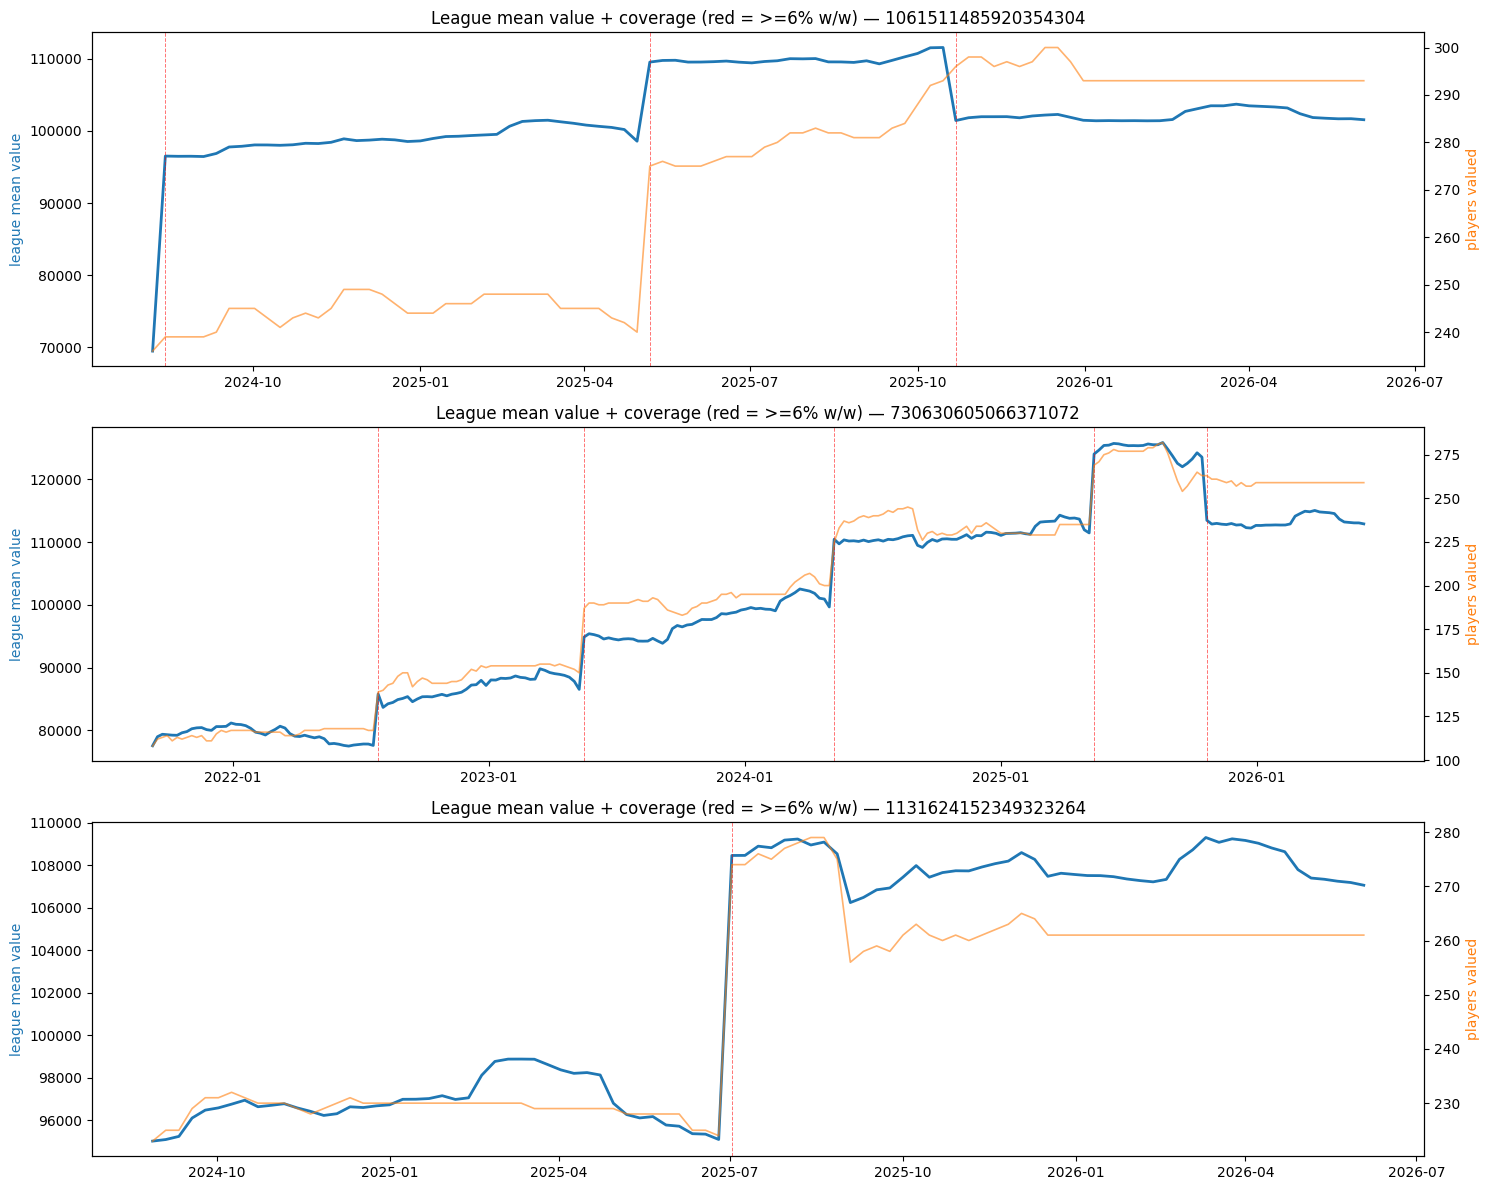

In [13]:
lins=[l for l in agg_k["league_lineage_id"].unique().to_list() if l]
fig,axes=plt.subplots(len(lins),1,figsize=(15,4*len(lins)),squeeze=False)
for ax,lin in zip(axes[:,0],lins):
    s=agg_k.filter(pl.col("league_lineage_id")==lin).sort("date")
    ax.plot([d for d in s["date"]], s["league_mean"].to_list(), color="C0", lw=2, label="league mean value")
    ax2=ax.twinx(); ax2.plot([d for d in s["date"]], s["lg_players_valued"].to_list(), color="C1", lw=1.2, alpha=0.6, label="players valued (league)")
    for r in s.filter(pl.col("wow_pct").abs()>=6).iter_rows(named=True):
        ax.axvline(r["date"], color="red", ls="--", lw=0.7, alpha=0.55)
    ax.set_title(f"League mean value + coverage (red = >=6% w/w) — {lin}")
    ax.set_ylabel("league mean value",color="C0"); ax2.set_ylabel("players valued",color="C1")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.tight_layout(); fig.savefig(CACHE/"tvot_ktc_spikes.png",dpi=90,bbox_inches="tight"); plt.show()

## KTC power index with the calendar overlaid (NFL phases + league events)

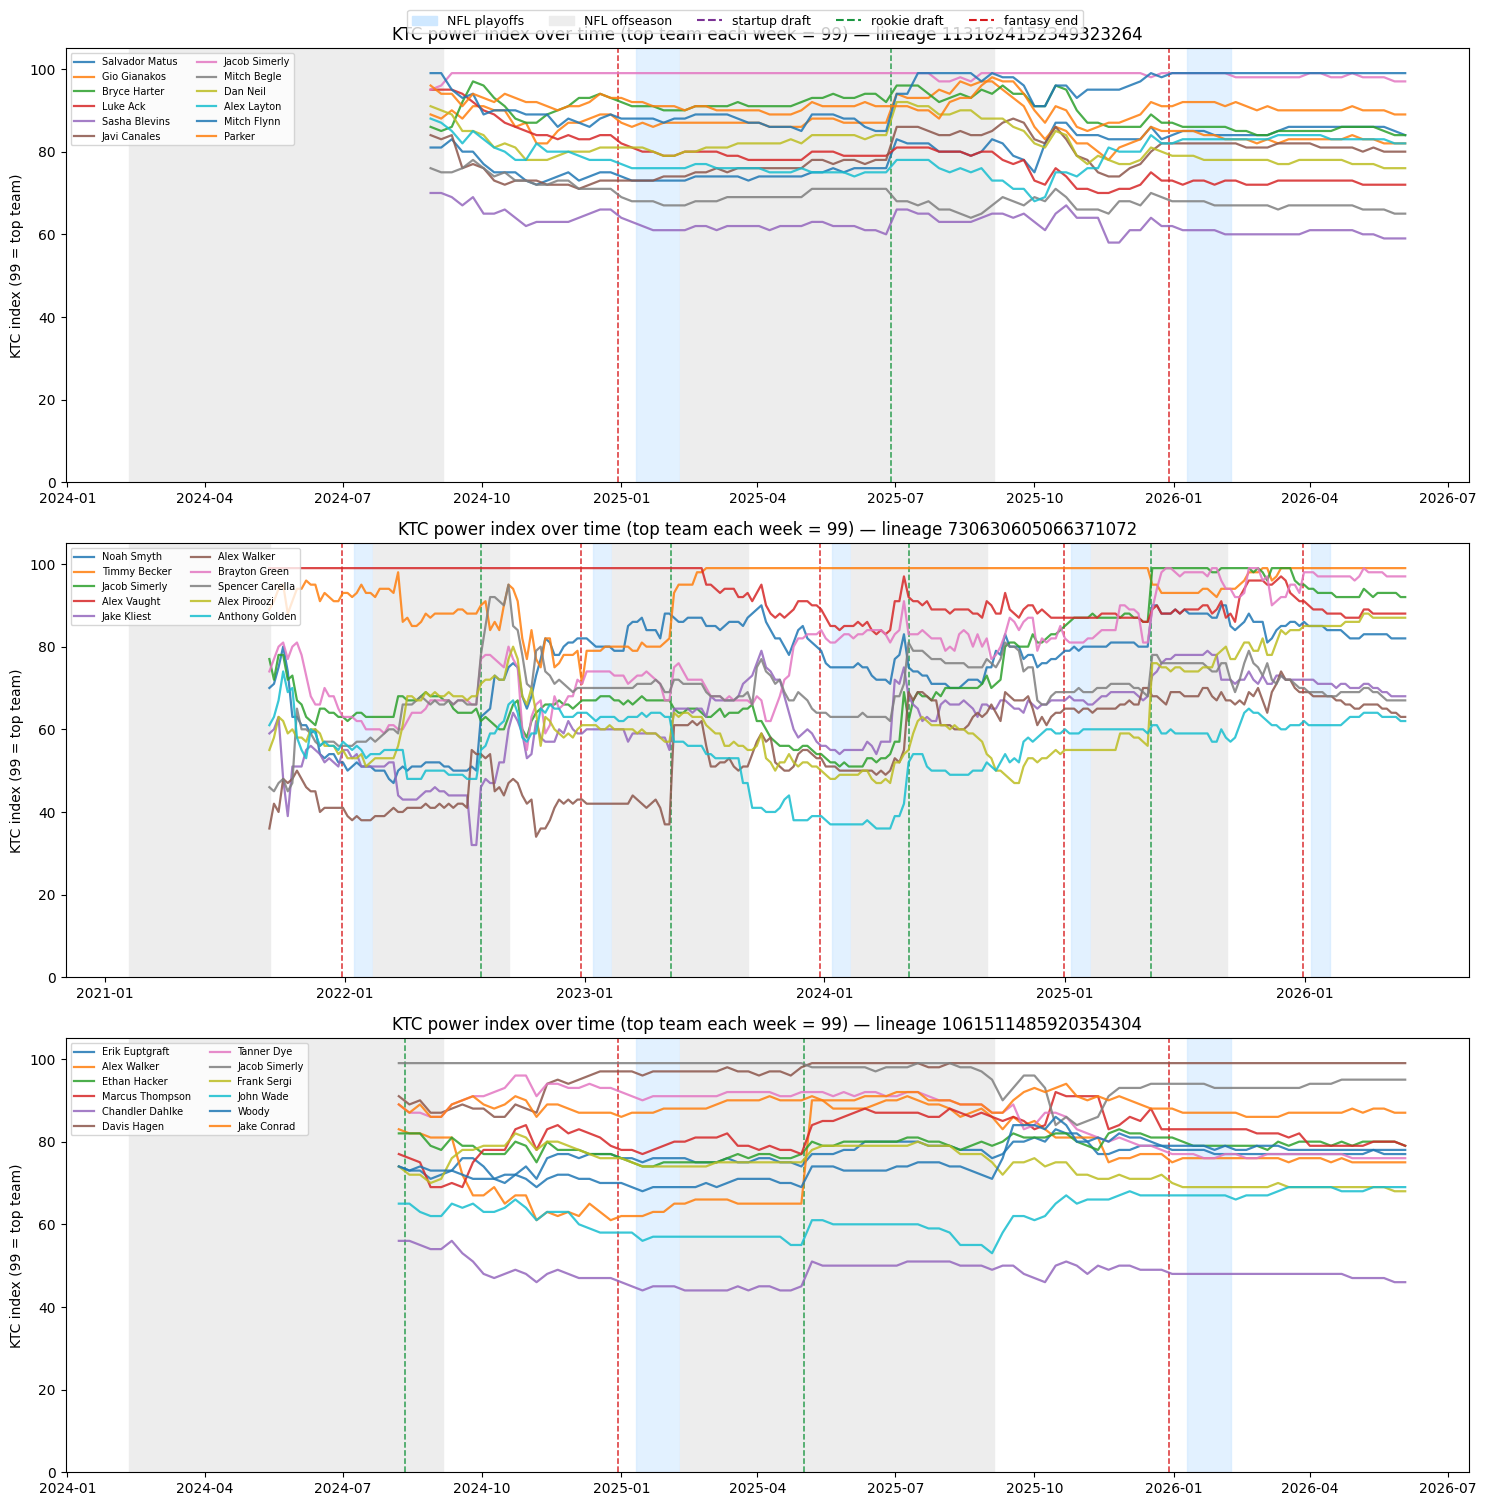

In [14]:
import matplotlib.patches as mpatches
dd_cal, le_cal = F.load_calendar()
# KTC 1-99 power index (players-only): top team each week = 99.
tvk_plus, _agg_cal = F.league_diagnostics(tv_ktc, fr_meta)

_starts  = dd_cal.filter(pl.col("is_nfl_season_start")).sort("date")["date"].to_list()
_pstarts = dd_cal.filter(pl.col("is_nfl_playoff_start")).sort("date")["date"].to_list()
_pends   = dd_cal.filter(pl.col("is_nfl_playoff_end")).sort("date")["date"].to_list()
EV_COLOR = {"startup_draft": "#7b3294", "rookie_draft": "#1a9641", "fantasy_end": "#d7191c"}

def plot_with_calendar(tv, col="ktc_index", title="KTC power index over time (top team each week = 99)"):
    lins = [l for l in tv["league_lineage_id"].unique().to_list() if l is not None]
    fig, axes = plt.subplots(len(lins), 1, figsize=(15, 5*len(lins)), squeeze=False)
    for ax, lin in zip(axes[:, 0], lins):
        sub = tv.filter((pl.col("league_lineage_id") == lin) & (pl.col("total_value") > 0))
        if sub.height == 0:
            continue
        x0, x1 = sub["date"].min(), sub["date"].max()
        for ps, pe in zip(_pstarts, _pends):
            if pe >= x0 and ps <= x1: ax.axvspan(ps, pe, color="#cfe8ff", alpha=0.6, zorder=0)
        for pe in _pends:
            nxt = [s for s in _starts if s > pe]
            if nxt and nxt[0] >= x0 and pe <= x1: ax.axvspan(pe, nxt[0], color="0.93", zorder=0)
        for fid in sub["franchise_id"].unique().to_list():
            s = sub.filter(pl.col("franchise_id") == fid).sort("date")
            ax.plot([d for d in s["date"]], s[col].to_list(), lw=1.6, alpha=0.85,
                    label=(s["current_team_name"][0] or fid), zorder=2)
        for r in le_cal.filter(pl.col("league_lineage_id") == lin).iter_rows(named=True):
            if r["event_date"] is not None and x0 <= r["event_date"] <= x1:
                ax.axvline(r["event_date"], color=EV_COLOR.get(r["event_type"], "gray"),
                           ls="--", lw=1.1, alpha=0.9, zorder=1)
        ax.set_title(f"{title} — lineage {lin}"); ax.set_ylabel("KTC index (99 = top team)")
        ax.set_ylim(0, 105)
        ax.legend(fontsize=7, ncol=2, loc="upper left")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    legend = [mpatches.Patch(color="#cfe8ff", label="NFL playoffs"),
              mpatches.Patch(color="0.93", label="NFL offseason"),
              plt.Line2D([], [], color=EV_COLOR["startup_draft"], ls="--", label="startup draft"),
              plt.Line2D([], [], color=EV_COLOR["rookie_draft"], ls="--", label="rookie draft"),
              plt.Line2D([], [], color=EV_COLOR["fantasy_end"], ls="--", label="fantasy end")]
    fig.legend(handles=legend, loc="upper center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, 1.005))
    fig.tight_layout(); return fig

fig = plot_with_calendar(tvk_plus)
fig.savefig(CACHE/"tvot_ktc_calendar.png", dpi=90, bbox_inches="tight"); plt.show()

## Caveats / where to look if it's wrong
- **Pick valuation is round-level** (KTC tier=Mid; FC round-generic). The standings-based tier/slot
  refinement is a documented v2 knob (see `fact-pick-values` memory), not applied here.
- **FantasyCalc** has no history before ~2025-10, so its curves are flat-zero before then — expected.
- **KTC** player values go back to ~2020-04; a player drafted later contributes 0 before he had a value.
- Ownership is the SCD2 ledger; `is_current` was validated to reproduce the latest snapshot exactly.
  A wrong curve most likely means a value-join issue, not ownership.

> **Early-era coverage (measured):** on 2021-10-01 the Stuck lineage rostered 284 players but only **113 (~40%) had a KTC value** then — KTC's historical rankings were top-heavy, so depth players score 0. Value *dates* are dense (365 in 2021), so this is **player coverage, not date sparsity**. Early team values therefore **undercount roster depth**, and some of the 2021→2024 rise is KTC widening its coverage, not pure appreciation. Read early levels as a floor.